# Healthcare Claims Cost Prediction & Risk Segmentation

This notebook analyzes healthcare insurance charges and builds an actuarial-style claim severity model.  
The goal is to estimate expected healthcare costs from policyholder risk factors and segment individuals into interpretable risk tiers.


## 1. Import Libraries

These libraries are used for data manipulation, visualization, regression modeling, Gamma GLM modeling, and model evaluation.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Load Dataset

The dataset contains policyholder characteristics and healthcare charges.  
The target variable is `charges`, which represents the realized healthcare cost.


In [3]:
df = pd.read_csv("../data/insurance.csv")

df.head()


,age,sex,bmi,children,smoker,region,charges,bmi_category,bmi_group,predicted_charges,risk_tier
0,19,female,27.900,0,yes,southwest,16884.92,Overweight,Medium BMI (25-30),15468.57,Severe Risk
1,18,male,33.770,1,no,southeast,1725.55,Obese,High BMI (>30),4010.44,Low Risk
2,28,male,33.000,3,no,southeast,4449.46,Obese,High BMI (>30),6305.84,Moderate Risk
3,33,male,22.705,0,no,northwest,21984.47,Normal,Low BMI (<25),5121.48,Low Risk
4,32,male,28.880,0,no,northwest,3866.86,Overweight,Medium BMI (25-30),5166.02,Low Risk


## 3. Initial Data Inspection

Before modeling, we inspect the dataset structure, variable types, missing values, and summary statistics.


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                1338 non-null   int64  
 1   sex                1338 non-null   str    
 2   bmi                1338 non-null   float64
 3   children           1338 non-null   int64  
 4   smoker             1338 non-null   str    
 5   region             1338 non-null   str    
 6   charges            1338 non-null   float64
 7   bmi_category       1338 non-null   str    
 8   bmi_group          1338 non-null   str    
 9   predicted_charges  1338 non-null   float64
 10  risk_tier          1338 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 115.1 KB


In [5]:
df.describe()


,age,bmi,children,charges,predicted_charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422280,13892.809365
std,14.049960,6.098187,1.205493,12110.011259,13535.044023
min,18.000000,15.960000,0.000000,1121.870000,2571.890000
25%,27.000000,26.296250,0.000000,4740.287500,5767.102500
50%,39.000000,30.400000,1.000000,9382.030000,9232.390000
75%,51.000000,34.693750,2.000000,16639.915000,14193.582500
max,64.000000,53.130000,5.000000,63770.430000,80053.930000


In [6]:
df.isnull().sum()


age                  0
sex                  0
bmi                  0
children             0
smoker               0
region               0
charges              0
bmi_category         0
bmi_group            0
predicted_charges    0
risk_tier            0
dtype: int64

## 4. Data Cleaning and Feature Engineering

We round healthcare charges to cents for cleaner reporting.  
We also create BMI categories to support actuarial-style risk segmentation.


In [7]:
df["charges"] = df["charges"].round(2)

df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

df.head()


,age,sex,bmi,children,smoker,region,charges,bmi_category,bmi_group,predicted_charges,risk_tier
0,19,female,27.900,0,yes,southwest,16884.92,Overweight,Medium BMI (25-30),15468.57,Severe Risk
1,18,male,33.770,1,no,southeast,1725.55,Obese,High BMI (>30),4010.44,Low Risk
2,28,male,33.000,3,no,southeast,4449.46,Obese,High BMI (>30),6305.84,Moderate Risk
3,33,male,22.705,0,no,northwest,21984.47,Normal,Low BMI (<25),5121.48,Low Risk
4,32,male,28.880,0,no,northwest,3866.86,Overweight,Medium BMI (25-30),5166.02,Low Risk


## 5. Exploratory Data Analysis

This section investigates the distribution of healthcare charges and the relationship between key risk factors and cost severity.


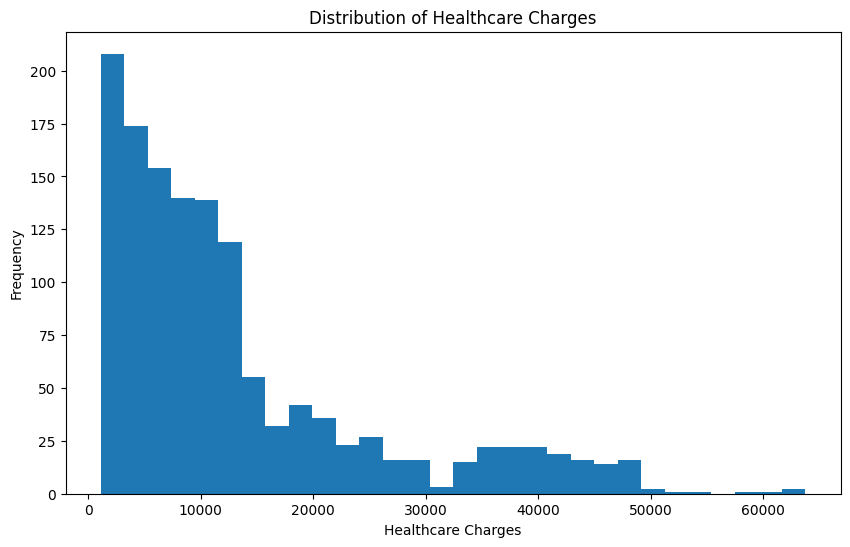

In [8]:
plt.figure(figsize=(10, 6))

plt.hist(df["charges"], bins=30)

plt.xlabel("Healthcare Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Healthcare Charges")

plt.show()


### Smoker vs Non-Smoker Cost Analysis

Smoking status is expected to be one of the strongest claim severity drivers.  
We compare average charges and distributional differences between smokers and non-smokers.


In [9]:
df.groupby("smoker")["charges"].agg(["mean", "median", "std", "min", "max"])


,mean,median,std,min,max
smoker,,,,,
no,8434.268299,7345.405,5993.781789,1121.87,36910.61
yes,32050.231898,34456.350,11541.547246,12829.46,63770.43


<Figure size 1000x600 with 0 Axes>

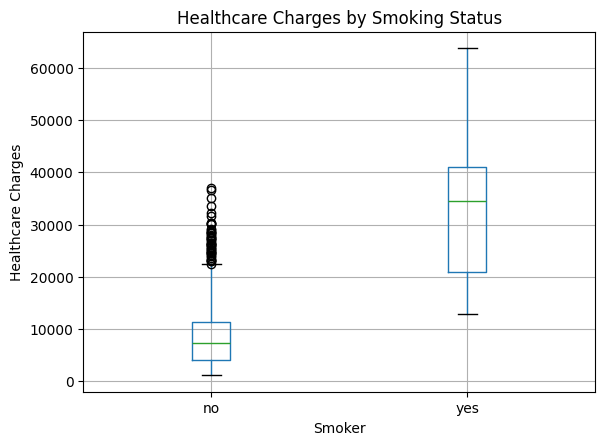

In [10]:
plt.figure(figsize=(10, 6))

df.boxplot(column="charges", by="smoker")

plt.title("Healthcare Charges by Smoking Status")
plt.suptitle("")
plt.xlabel("Smoker")
plt.ylabel("Healthcare Charges")

plt.show()


### BMI and Smoking Combined Risk Analysis

This chart compares average healthcare charges across BMI categories and smoking status.  
It directly shows how behavioral and physical risk factors combine to affect expected healthcare cost.


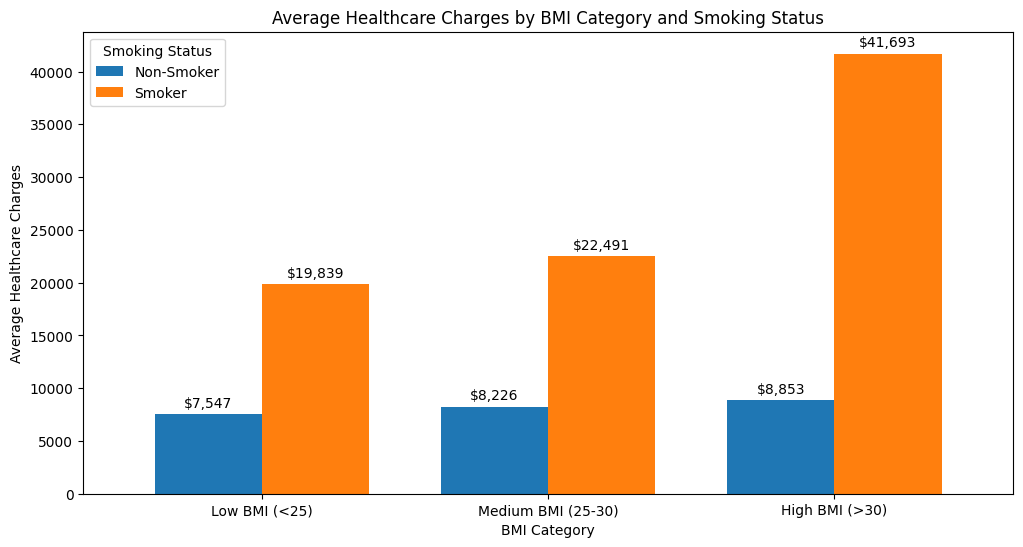

In [11]:
df["bmi_group"] = pd.cut(
    df["bmi"],
    bins=[0, 25, 30, 100],
    labels=["Low BMI (<25)", "Medium BMI (25-30)", "High BMI (>30)"]
)

bmi_smoker_avg = df.groupby(["bmi_group", "smoker"])["charges"].mean().unstack()
bmi_smoker_avg = bmi_smoker_avg[["no", "yes"]]

ax = bmi_smoker_avg.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.75
)

plt.title("Average Healthcare Charges by BMI Category and Smoking Status")
plt.xlabel("BMI Category")
plt.ylabel("Average Healthcare Charges")
plt.xticks(rotation=0)
plt.legend(["Non-Smoker", "Smoker"], title="Smoking Status")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"${v:,.0f}" for v in container.datavalues],
        padding=3
    )

plt.savefig(
    "../visuals/charges_by_bmi_and_smoking_status.png",
    bbox_inches="tight"
)

plt.show()


### Age and Healthcare Charges

Age is a core actuarial rating factor.  
This scatterplot shows how healthcare charges vary across age, with smoking status highlighted.


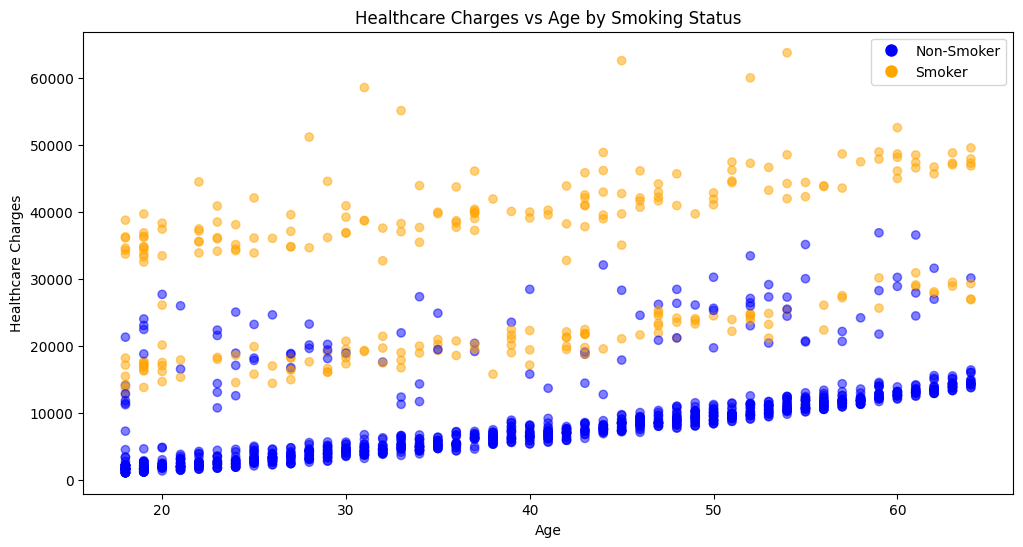

In [12]:
colors = df["smoker"].map({
    "no": "blue",
    "yes": "orange"
})

plt.figure(figsize=(12, 6))

plt.scatter(
    df["age"],
    df["charges"],
    c=colors,
    alpha=0.5
)

plt.title("Healthcare Charges vs Age by Smoking Status")
plt.xlabel("Age")
plt.ylabel("Healthcare Charges")

plt.legend(
    handles=[
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor="blue", label="Non-Smoker", markersize=10),
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor="orange", label="Smoker", markersize=10)
    ]
)

plt.savefig(
    "../visuals/charges_vs_age_smoking.png",
    bbox_inches="tight"
)

plt.show()


### Correlation Matrix

The correlation matrix gives a quick numerical overview of relationships between numeric variables.


In [13]:
df.corr(numeric_only=True)


,age,bmi,children,charges,predicted_charges
age,1.000000,0.109272,0.042469,0.299008,0.390632
bmi,0.109272,1.000000,0.012759,0.198341,0.112307
children,0.042469,0.012759,1.000000,0.067998,0.111445
charges,0.299008,0.198341,0.067998,1.000000,0.825818
predicted_charges,0.390632,0.112307,0.111445,0.825818,1.000000


## 6. Linear Regression Baseline Model

A linear regression model is used as a simple baseline.  
This gives interpretable additive dollar effects for each risk factor.


In [14]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

X.head()


,age,bmi,children,predicted_charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,bmi_group_Medium BMI (25-30),bmi_group_High BMI (>30),risk_tier_Low Risk,risk_tier_Moderate Risk,risk_tier_Severe Risk
0,19,27.900,0,15468.57,False,True,False,False,True,False,True,False,True,False,False,False,True
1,18,33.770,1,4010.44,True,False,False,True,False,False,False,True,False,True,True,False,False
2,28,33.000,3,6305.84,True,False,False,True,False,False,False,True,False,True,False,True,False
3,33,22.705,0,5121.48,True,False,True,False,False,True,False,False,False,False,True,False,False
4,32,28.880,0,5166.02,True,False,True,False,False,False,True,False,True,False,True,False,False


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)


In [16]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression MAE:", linear_mae)
print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R^2:", linear_r2)


Linear Regression MAE: 4243.046454367747
Linear Regression RMSE: 5762.230688743908
Linear Regression R^2: 0.7861283525061811


In [17]:
linear_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

linear_coefficients.sort_values(
    by="Coefficient",
    ascending=False
).reset_index(drop=True)


,Feature,Coefficient
0,smoker_yes,19635.956490
1,bmi_group_High BMI (>30),2701.047527
2,bmi_category_Obese,2701.047527
3,bmi_category_Normal,1946.449205
4,bmi_group_Medium BMI (25-30),1133.471218
5,bmi_category_Overweight,1133.471218
6,risk_tier_Low Risk,1064.052223
7,children,315.299925
8,age,214.924744
9,risk_tier_Moderate Risk,190.903872


## 7. Gamma GLM Claim Severity Model

Healthcare charges are positive and right-skewed, which makes a Gamma GLM with a log link more appropriate for actuarial severity modeling.  
The log link allows risk factors to affect expected costs multiplicatively.


In [18]:
X_glm = sm.add_constant(X).astype(float)
y_glm = y.astype(float)

gamma_model = sm.GLM(
    y_glm,
    X_glm,
    family=sm.families.Gamma(
        link=sm.families.links.Log()
    )
)

gamma_results = gamma_model.fit()

print(gamma_results.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                charges   No. Observations:                 1338
Model:                            GLM   Df Residuals:                     1322
Model Family:                   Gamma   Df Model:                           15
Link Function:                    Log   Scale:                         0.48565
Method:                          IRLS   Log-Likelihood:                -13295.
Date:                Thu, 28 May 2026   Deviance:                       311.26
Time:                        16:19:48   Pearson chi2:                     642.
No. Iterations:                    16   Pseudo R-squ. (CS):             0.6822
Covariance Type:            nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

### GLM Multiplicative Effects

Because the Gamma GLM uses a log link, exponentiating coefficients converts them into multiplicative risk factors.


In [19]:
glm_effects = pd.DataFrame({
    "Feature": gamma_results.params.index,
    "Coefficient": gamma_results.params.values,
    "Multiplier": np.exp(gamma_results.params.values),
    "Percent_Change": (np.exp(gamma_results.params.values) - 1) * 100,
    "P_Value": gamma_results.pvalues.values
})

glm_effects.sort_values(
    by="Multiplier",
    ascending=False
).reset_index(drop=True)


,Feature,Coefficient,Multiplier,Percent_Change,P_Value
0,const,6.613974,745.439470,74443.946953,1.305803e-90
1,smoker_yes,2.671166,14.456822,1345.682158,4.798555e-24
2,bmi_category_Normal,0.347217,1.415124,41.512409,3.405743e-02
3,bmi_group_High BMI (>30),0.286725,1.332058,33.205765,3.319230e-03
4,bmi_category_Obese,0.286725,1.332058,33.205765,3.319230e-03
5,risk_tier_Low Risk,0.253050,1.287948,28.794818,8.079190e-02
6,bmi_group_Medium BMI (25-30),0.179985,1.197199,19.719914,3.446813e-02
7,bmi_category_Overweight,0.179985,1.197199,19.719914,3.446813e-02
8,children,0.140038,1.150317,15.031694,2.619715e-11
9,risk_tier_Moderate Risk,0.101324,1.106635,10.663472,2.053286e-01


## 8. Model Predictions and Validation

The Gamma GLM predictions represent estimated expected healthcare charges for each policyholder.


In [20]:
glm_predictions = gamma_results.predict(X_glm)

df["predicted_charges"] = glm_predictions.round(2)


In [21]:
glm_mae = mean_absolute_error(y_glm, glm_predictions)
glm_rmse = np.sqrt(mean_squared_error(y_glm, glm_predictions))
glm_r2 = r2_score(y_glm, glm_predictions)

print("Gamma GLM MAE:", glm_mae)
print("Gamma GLM RMSE:", glm_rmse)
print("Gamma GLM R^2:", glm_r2)


Gamma GLM MAE: 3959.2701271075844
Gamma GLM RMSE: 6385.656363972661
Gamma GLM R^2: 0.7217426146491923


In [22]:
comparison = pd.DataFrame({
    "Actual_Charges": y_glm.round(2),
    "Predicted_Charges": df["predicted_charges"]
})

comparison["Percent_Difference"] = (
    abs(
        comparison["Actual_Charges"]
        - comparison["Predicted_Charges"]
    )
    / comparison["Actual_Charges"]
) * 100

comparison["Percent_Difference"] = (
    comparison["Percent_Difference"]
    .round(2)
    .astype(str) + "%"
)

comparison.head(10)


,Actual_Charges,Predicted_Charges,Percent_Difference
0,16884.92,18057.17,6.94%
1,1725.55,3557.62,106.17%
2,4449.46,6001.23,34.88%
3,21984.47,5176.73,76.45%
4,3866.86,5171.28,33.73%
5,3756.62,4722.37,25.71%
6,8240.59,9542.15,15.79%
7,7281.51,8469.53,16.32%
8,6406.41,7640.35,19.26%
9,28923.14,13016.32,55.0%


### Actual vs Predicted Healthcare Charges

This chart compares realized healthcare charges to Gamma GLM predicted charges.  
The dashed line represents perfect prediction.


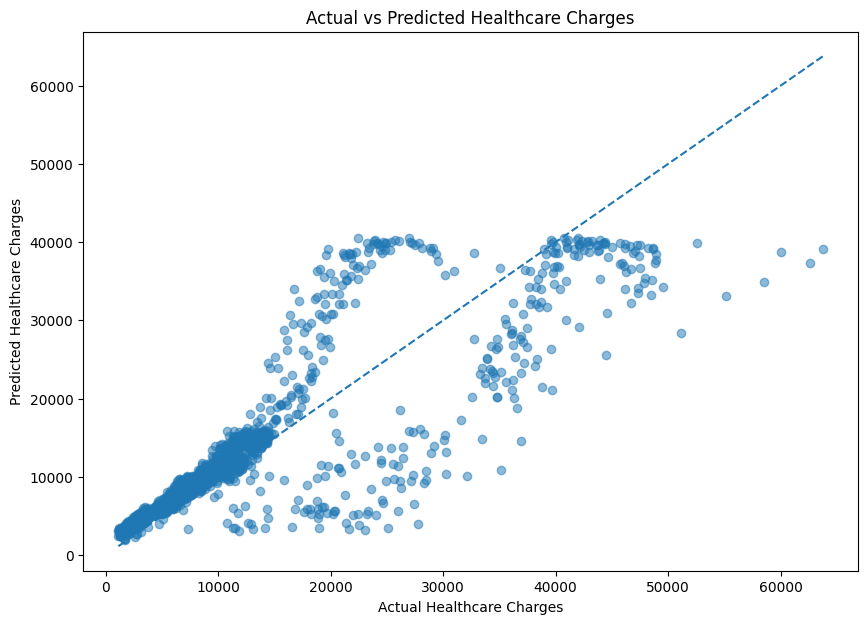

In [23]:
plt.figure(figsize=(10, 7))

plt.scatter(
    y_glm,
    glm_predictions,
    alpha=0.5
)

plt.plot(
    [y_glm.min(), y_glm.max()],
    [y_glm.min(), y_glm.max()],
    linestyle="--"
)

plt.xlabel("Actual Healthcare Charges")
plt.ylabel("Predicted Healthcare Charges")
plt.title("Actual vs Predicted Healthcare Charges")

plt.savefig(
    "../visuals/actual_vs_predicted_charges.png",
    bbox_inches="tight"
)

plt.show()


## 9. Risk Tier Segmentation

Predicted charges are used to segment individuals into four actuarial-style risk tiers.  
This turns the severity model into an interpretable underwriting and risk classification framework.


In [24]:
df["risk_tier"] = pd.qcut(
    df["predicted_charges"],
    q=4,
    labels=[
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Severe Risk"
    ]
)

df["risk_tier"].value_counts()


risk_tier
Low Risk         335
Severe Risk      335
Moderate Risk    334
High Risk        334
Name: count, dtype: int64

In [25]:
df.groupby("risk_tier")[["charges", "predicted_charges"]].mean()


,charges,predicted_charges
risk_tier,,
Low Risk,4210.221851,4136.036836
Moderate Risk,7612.871886,7601.195719
High Risk,12170.441467,12151.030329
Severe Risk,29067.982179,29628.075701


In [26]:
df.to_csv(
    "../data/insurance.csv",
    index=False
)


## 10. Key Findings

- Smoking status was the strongest healthcare severity driver.
- The Gamma GLM estimated that smokers have substantially higher expected healthcare charges than non-smokers, holding other variables constant.
- Obesity and age also increased expected healthcare costs.
- The model captured broad claim severity patterns but still showed large individual prediction errors, which is realistic in healthcare claims due to hidden medical factors and tail risk.
- Risk tiering converted model predictions into an actuarial-style segmentation framework.
